# Small-Scale ERP Image Classification

This notebook studies how far very small ERP images can go in a binary classification setting (`sigmoid` vs `no_class`).
The main goal is not only to compare classifiers, but also to understand how simulation settings influence downstream performance on the labeled real fixation dataset.

The notebook contains two connected workflows:

1. **Simulator-first search (original workflow)**
   A simulation parameter search is run first. The search methods are `broad_random`, `lhs_calibrated`, and `mc_random_search`.
   In this workflow, candidate simulator settings are scored with a **proxy matching objective** that compares simulated `sigmoid` images to real `sigmoid` images in feature space.
   Only after that search do we generate larger simulated datasets, train several models, and rank the final downstream results on real data.

2. **Model-first direct search (Dense NN low-pass workflow)**
   This second workflow directly optimizes simulator settings for `dense_nn_gpu` under `lowpass = true`.
   Instead of using only the proxy matching score, it evaluates candidates by actually training the Dense NN and measuring real-data classification quality.
   It starts from the normal baseline configuration (`base_cfg`) and can additionally reuse top settings from previous runs as seed configurations.

Conceptually, the notebook therefore lets you compare two philosophies:
- **Proxy-guided simulation search**: cheaper, more stable, more model-agnostic
- **Direct task-driven search**: more expensive, but directly aligned with final classification performance

Typical reading order:
- adjust the shared experiment controls
- run the original simulator-first workflow
- inspect the ranked model results and the representative settings table
- inspect concrete TP / TN / FP / FN examples
- optionally run the Dense-NN low-pass direct search for a more task-driven follow-up optimization

Note:
The labeled real `sigmoid` / `no_class` examples in this repository come from the fixation dataset plus Label Studio annotations.


In [1]:
import Pkg

ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

Pkg.activate(joinpath(pwd(), "..", "data_generation"))

using Flux
using MLUtils
using StatsBase
using CairoMakie
using Random
using Distributions
using Statistics
using DecisionTree
using LIBSVM
using CUDA
using cuDNN
using CSV
using DataFrames
using HDF5

if !isdefined(Main, :ERPGen)
    include(joinpath(pwd(), "..", "data_generation", "erpgen.jl"))
end
using .ERPGen

if !isdefined(Main, :ERPImageUtils)
    include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
end
using .ERPImageUtils

include(joinpath(pwd(), "simulation_small_scale_helpers.jl"))
using .SmallScaleERPClassification

println("Active project: ", Base.active_project())
println("Flux version: ", Base.pkgversion(Flux))
println("CUDA functional: ", CUDA.functional())


  Activating project at `~/Dokumente/BA2/notebooks/data_generation`


Active project: /home/benjamin/Dokumente/BA2/notebooks/data_generation/Project.toml
Flux version: 0.16.9
CUDA functional: true


## Experiment Controls

Edit the next code cell before launching the heavy run. This cell defines the global budget and determines how expensive the original workflow will be.

Important controls in the original workflow:

- `BASE_SEED`
  Runtime-generated random seed based on `time_ns()`. Re-running the cell creates a fresh seed for the full workflow.

- `TARGET_SIZES`
  The ERP image resolutions that will be evaluated. In this notebook the comparison is intentionally small-scale: `2x2`, `4x4`, `8x8`, and `16x16`.

- `LOWPASS_CHOICES`
  Whether a low-pass style prefilter is applied before resizing. This matters because aggressive downsampling can distort the ERP image structure.

- `STRATEGY_NAMES`
  The simulation-search strategies that will be executed:
  - `:broad_random`: random settings drawn from the broad global parameter ranges
  - `:lhs_calibrated`: Latin hypercube sampling over the global ranges, then keep the best candidates
  - `:mc_random_search`: Monte Carlo random sampling over the global ranges, then keep the best candidates

- `CALIBRATION_CANDIDATES`
  This is the number of parameter candidates evaluated **per calibrated search method** in the original workflow.
  If you increase this, the proxy-based simulator search becomes more thorough, but more expensive.

- `CALIBRATION_TOP_K`
  After scoring all candidates in `lhs_calibrated` and `mc_random_search`, only the top `K` settings are retained and used to generate the larger simulated datasets.

- `PROBE_N_PER_PATTERN`
  Number of simulated examples per class used during the **small proxy calibration probe**.
  This controls the cost and stability of the simulator-matching stage before full model training starts.

- `N_PER_PATTERN`
  Number of repetitions per pattern used when the final simulated training datasets are built for each strategy.
  Larger values give the downstream models more simulated training data, but also increase runtime and memory usage.

- `NN_BATCH_SIZE`, `NN_EPOCHS`, `NN_LR`, `RF_TREES`
  Downstream model-training hyperparameters used after the simulator settings have been selected.

Rule of thumb:
- If you want to spend more compute on the **original proxy-guided search**, first increase `CALIBRATION_CANDIDATES`.
- If you want to spend more compute on the **final downstream training**, increase `N_PER_PATTERN` or `NN_EPOCHS`.


In [2]:
BASE_SEED = Int(time_ns())

TARGET_SIZES = SmallScaleERPClassification.TARGET_SIZES
LOWPASS_CHOICES = SmallScaleERPClassification.LOWPASS_CHOICES
STRATEGY_NAMES = [:broad_random, :lhs_calibrated, :mc_random_search]

N_PER_PATTERN = 1000
CALIBRATION_CANDIDATES = 18
CALIBRATION_TOP_K = 4
PROBE_N_PER_PATTERN = 128

NN_BATCH_SIZE = 32
NN_EPOCHS = 30
NN_LR = 1f-3
RF_TREES = 200

println("Seed (time_ns): ", BASE_SEED)
println("Target sizes: ", TARGET_SIZES)
println("Low-pass settings: ", LOWPASS_CHOICES)
println("Strategies: ", STRATEGY_NAMES)
println("Simulated repetitions per class pair: ", N_PER_PATTERN)


Seed (time_ns): 10385745032189
Target sizes: [(2, 2), (4, 4), (8, 8), (16, 16)]
Low-pass settings: (true, false)
Strategies: [:broad_random, :lhs_calibrated, :mc_random_search]
Simulated repetitions per class pair: 1000


## Run Experiment

This is the main execution block for the **original simulator-first workflow**. It performs four stages:

1. **Load real labeled ERP images**
   Real fixation data are loaded, converted into ERP images, and cached for all requested resolutions and low-pass conditions.

2. **Search simulator settings**
   The simulator search is performed with the three strategies listed above.
   In this stage, the calibrated methods (`lhs_calibrated` and `mc_random_search`) do **not** yet train the final classifier.
   Instead, they score candidate simulator settings by comparing simulated `sigmoid` images with real `sigmoid` images in feature space.

   The proxy score combines two terms:
   - a z-normalized feature-mean distance (`zdist`)
   - an RBF MMD term (`mmd2`)

   Lower proxy scores indicate that the simulated `sigmoid` images look more similar to the real `sigmoid` images under that feature representation.

3. **Generate larger simulated datasets**
   For each selected strategy, simulated `sigmoid` and `no_class` images are generated at every requested resolution and low-pass condition.

4. **Train downstream models and evaluate on real data**
   Three models are trained on the simulated data and tested immediately on the real labeled dataset:
   - `dense_nn_gpu`
   - `random_forest`
   - `svm_rbf`

Final ranking in the original workflow is then based on real-data downstream metrics, mainly:
- `balanced_accuracy`
- `macro_f1`

This separation is important:
- the **search stage** uses a proxy objective to calibrate the simulator
- the **final model ranking** uses real classification performance

This design is useful when you want to keep the simulator search relatively model-agnostic and cheaper than a full nested direct optimization.


In [3]:
experiment = run_small_scale_experiment(
    n_per_pattern = N_PER_PATTERN,
    target_sizes = TARGET_SIZES,
    lowpass_choices = LOWPASS_CHOICES,
    strategy_names = STRATEGY_NAMES,
    seed = BASE_SEED,
    calibration_candidates = CALIBRATION_CANDIDATES,
    calibration_top_k = CALIBRATION_TOP_K,
    probe_n_per_pattern = PROBE_N_PER_PATTERN,
    nn_batch_size = NN_BATCH_SIZE,
    nn_epochs = NN_EPOCHS,
    nn_lr = NN_LR,
    rf_trees = RF_TREES,
)


Loading real labelled ERP images...
  real images processed: 50/488
  real images processed: 100/488
  real images processed: 150/488
  real images processed: 200/488
  real images processed: 250/488
  real images processed: 300/488
  real images processed: 350/488
  real images processed: 400/488
  real images processed: 450/488
  real images processed: 488/488
Real calibration sigmoid images: 36
Searching simulation strategies...

=== Strategy broad_random | repetitions=1000 ===
  processed repetitions: 100/1000
  processed repetitions: 200/1000
  processed repetitions: 300/1000
  processed repetitions: 400/1000
  processed repetitions: 500/1000
  processed repetitions: 600/1000
  processed repetitions: 700/1000
  processed repetitions: 800/1000
  processed repetitions: 900/1000
  processed repetitions: 1000/1000

Condition 2x2 | with low-pass
    dense_nn epoch 1/30 | loss=1.12425
    dense_nn epoch 6/30 | loss=0.69191
    dense_nn epoch 12/30 | loss=0.68235
    dense_nn epoch 18/30

(results_df = 72×16 DataFrame
 Row │ strategy          resolution  width  height  lowpass  model          ba ⋯
     │ String            String      Int64  Int64   Bool     String         Fl ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ broad_random      2x2             2       2     true  dense_nn_gpu      ⋯
   2 │ broad_random      2x2             2       2     true  random_forest
   3 │ broad_random      2x2             2       2     true  svm_rbf
   4 │ broad_random      2x2             2       2    false  dense_nn_gpu
   5 │ broad_random      2x2             2       2    false  random_forest     ⋯
   6 │ broad_random      2x2             2       2    false  svm_rbf
   7 │ broad_random      4x4             4       4     true  dense_nn_gpu
   8 │ broad_random      4x4             4       4     true  random_forest
  ⋮  │        ⋮              ⋮         ⋮      ⋮        ⋮           ⋮           ⋱
  66 │ mc_random_search  8x8             8      

In [4]:
result_tables = summarize_results(experiment.results_df)
result_tables.summary


Row,strategy,model,mean_balanced_accuracy,mean_macro_f1
,String,String,Float64,Float64
1,broad_random,random_forest,0.576573,0.440339
2,lhs_calibrated,svm_rbf,0.571611,0.46957
3,lhs_calibrated,random_forest,0.556462,0.456007
4,broad_random,dense_nn_gpu,0.555079,0.416041
5,lhs_calibrated,dense_nn_gpu,0.544847,0.45343
6,broad_random,svm_rbf,0.543434,0.432725
7,mc_random_search,random_forest,0.539086,0.440424
8,mc_random_search,svm_rbf,0.529821,0.441875
9,mc_random_search,dense_nn_gpu,0.52701,0.419844


In [5]:
result_tables.ranked[:, [:strategy, :resolution, :lowpass, :model, :balanced_accuracy, :macro_f1, :train_time_s]]


Row,strategy,resolution,lowpass,model,balanced_accuracy,macro_f1,train_time_s
,String,String,Bool,String,Float64,Float64,Float64
1,broad_random,8x8,true,dense_nn_gpu,0.686332,0.507071,3.8687
2,broad_random,16x16,true,dense_nn_gpu,0.680678,0.524811,2.04352
3,lhs_calibrated,16x16,true,svm_rbf,0.679449,0.548305,0.645405
4,mc_random_search,8x8,true,random_forest,0.679449,0.548305,0.112476
5,lhs_calibrated,8x8,true,random_forest,0.677729,0.558946,0.107317
6,mc_random_search,16x16,true,random_forest,0.6706,0.536795,0.16838
7,lhs_calibrated,16x16,true,dense_nn_gpu,0.668879,0.54703,2.04445
8,lhs_calibrated,16x16,true,random_forest,0.668387,0.533977,0.176751
9,mc_random_search,16x16,true,svm_rbf,0.662856,0.527026,0.69353


## Ranked Settings Table

The table below follows the exact row order of `result_tables.ranked`.
That means the best-performing downstream model configuration appears at the top, followed by the second-best one, and so on.

For each ranked result row, the table attaches a representative simulator setting for the corresponding search strategy.
At the moment the notebook uses `setting_rank = 1`, which means:
- for `lhs_calibrated`, the best retained LHS setting is attached
- for `mc_random_search`, the best retained Monte Carlo setting is attached
- for `broad_random`, the first representative broad random setting is attached

This table is useful when you want to answer questions such as:
- Which downstream result is actually best?
- Which simulator strategy produced that result?
- Which concrete simulation parameter values are associated with that strategy?

In other words, this table links **performance ranking** and **simulator parameterization** in one place.


In [6]:
ranked_settings_table = build_ranked_settings_table(
    experiment;
    ranked_results = result_tables.ranked,
    setting_rank = 1,
)

ranked_settings_table


Row,result_rank,strategy,resolution,lowpass,model,balanced_accuracy,macro_f1,recall_no_class,recall_sigmoid,train_time_s,setting_source,setting_rank,setting_candidate,setting_score,setting_zdist,setting_mmd2,sim_mu_mean,sim_mu_std,sim_sigma_mean,sim_sigma_std,p100_width_mean,p100_width_std,n170_width_mean,n170_width_std,p300_width_mean,p300_width_std,p100_n170_gap_mean,p100_n170_gap_std,n170_p300_gap_mean,n170_p300_gap_std,p1_beta_mean,p1_beta_std,p3_beta_mean,p3_beta_std,n1_beta1_mean,n1_beta1_std,n1_beta2_mean,n1_beta2_std,n1_beta3_mean,n1_beta3_std,componentA_amp_mean,componentA_amp_std,componentB_amp_mean,componentB_amp_std,componentC_amp_mean,componentC_amp_std,noise_pink_mean,noise_pink_std,noise_white_mean,noise_white_std,noise_red_mean,noise_red_std,noise_exponential_mean,noise_exponential_std
,Int64,String,String,Bool,String,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,broad_random,8x8,true,dense_nn_gpu,0.686332,0.507071,0.650442,0.722222,3.8687,random_sample,1,missing,missing,missing,missing,4.81043,0.367436,0.745808,0.132583,0.199983,0.0163523,0.216631,0.00957051,0.423578,0.0373236,0.116151,0.0148752,0.23893,0.0117599,4.63928,1.50365,8.64914,0.817983,9.65794,0.882639,1.9342,0.880928,1.43916,0.166379,3.89249,0.707397,-12.9934,0.873545,4.54016,1.5137,21.5868,4.21178,24.1151,4.51382,10.8057,3.01357,37.1571,1.03085
2,2,broad_random,16x16,true,dense_nn_gpu,0.680678,0.524811,0.69469,0.666667,2.04352,random_sample,1,missing,missing,missing,missing,4.81043,0.367436,0.745808,0.132583,0.199983,0.0163523,0.216631,0.00957051,0.423578,0.0373236,0.116151,0.0148752,0.23893,0.0117599,4.63928,1.50365,8.64914,0.817983,9.65794,0.882639,1.9342,0.880928,1.43916,0.166379,3.89249,0.707397,-12.9934,0.873545,4.54016,1.5137,21.5868,4.21178,24.1151,4.51382,10.8057,3.01357,37.1571,1.03085
3,3,lhs_calibrated,16x16,true,svm_rbf,0.679449,0.548305,0.747788,0.611111,0.645405,lhs_top_candidate,1,10,0.363161,0.34941,0.0275027,4.62056,0.315501,0.200946,0.0606835,0.0628501,0.0325328,0.0963541,0.0145863,0.411756,0.0727977,0.0442451,0.0250194,0.16987,0.0196283,3.00294,1.79413,6.61747,1.17488,6.9635,1.06104,2.0086,0.519823,1.21323,0.433684,6.94478,0.578943,-18.3451,1.93259,5.35337,1.03772,25.49,4.70742,14.9332,2.497,22.1358,3.13288,16.0956,2.96449
4,4,mc_random_search,8x8,true,random_forest,0.679449,0.548305,0.747788,0.611111,0.112476,mc_top_candidate,1,9,0.365772,0.341481,0.0485829,3.38594,0.303642,0.819955,0.19771,0.12597,0.0271918,0.235179,0.0398522,0.440371,0.0573344,0.0792386,0.0132792,0.207262,0.0190617,7.57912,1.84701,9.42854,0.450851,3.44711,0.868161,3.45103,0.273908,1.79249,0.154214,2.73099,0.526948,-7.31175,0.6348,8.36973,1.53378,32.0519,2.24957,18.4585,3.19635,30.6322,2.37222,7.94258,3.41762
5,5,lhs_calibrated,8x8,true,random_forest,0.677729,0.558946,0.772124,0.583333,0.107317,lhs_top_candidate,1,10,0.363161,0.34941,0.0275027,4.62056,0.315501,0.200946,0.0606835,0.0628501,0.0325328,0.0963541,0.0145863,0.411756,0.0727977,0.0442451,0.0250194,0.16987,0.0196283,3.00294,1.79413,6.61747,1.17488,6.9635,1.06104,2.0086,0.519823,1.21323,0.433684,6.94478,0.578943,-18.3451,1.93259,5.35337,1.03772,25.49,4.70742,14.9332,2.497,22.1358,3.13288,16.0956,2.96449
6,6,mc_random_search,16x16,true,random_forest,0.6706,0.536795,0.730088,0.611111,0.16838,mc_top_candidate,1,9,0.365772,0.341481,0.0485829,3.38594,0.303642,0.819955,0.19771,0.12597,0.0271918,0.235179,0.0398522,0.440371,0.0573344,0.0792386,0.0132792,0.207262,0.0190617,7.57912,1.84701,9.42854,0.450851,3.44711,0.868161,3.45103,0.273908,1.79249,0.154214,2.73099,0.526948,-7.31175,0.6348,8.36973,1.53378,32.0519,2.24957,18.4585,3.19635,30.6322,2.37222,7.94258,3.41762
7,7,

## Performance Figures

This section is intended for visual summaries of the original workflow results.
Typical plots to place here are heatmaps across resolution and low-pass settings, or delta plots that show how much low-pass filtering helps or hurts per model and strategy.

Use this section when you want a high-level view of trends before inspecting individual settings or individual examples.


## Example Simulated Images

This section is for qualitative inspection of simulated ERP images.
It helps answer whether a strategy only looks good numerically, or whether the generated `sigmoid` / `no_class` examples also look plausible by eye across scales.

This is especially useful when comparing the broad random baseline against the calibrated strategies.


In [7]:
best_strategy_name, strategy_means = select_best_strategy(experiment.results_df)
strategy_means


Row,strategy,mean_metric
,String,Float64
1,broad_random,0.558362
2,lhs_calibrated,0.55764
3,mc_random_search,0.531972


## Confusion Example Diagnostics

This section moves from aggregate metrics to **concrete real examples**.
The idea is simple: a good score alone does not tell you *why* the model behaves the way it does.
To understand that, we inspect one real example for each confusion-matrix category:

- `TP`: real `sigmoid`, predicted `sigmoid`
- `TN`: real `no_class`, predicted `no_class`
- `FP`: real `no_class`, predicted `sigmoid`
- `FN`: real `sigmoid`, predicted `no_class`

How the section works:
- the first code cell replays the highest-ranked setting that still provides concrete TP / TN / FP / FN examples if possible
- the second code cell samples one example from each category and plots them with their own colorbar

Why this matters:
- `TP` and `TN` show what the model handles well
- `FP` shows what kind of non-sigmoid structure is mistakenly considered signal-like
- `FN` shows which real `sigmoid` cases are too weak, noisy, or structurally different from the learned simulator prior

Practical note:
Re-run only the plot cell if you want a new random set of TP / TN / FP / FN examples from the same evaluated setting.


In [8]:
best_confusion_bundle = build_confusion_example_bundle(
    experiment;
    ranked_results = result_tables.ranked,
    prefer_complete_confusion = true,
    nn_batch_size = NN_BATCH_SIZE,
    nn_epochs = NN_EPOCHS,
    nn_lr = NN_LR,
    rf_trees = RF_TREES,
    seed = BASE_SEED,
)

confusion_config_df = DataFrame([merge(
    best_confusion_bundle.selected_config,
    (
        complete_confusion = best_confusion_bundle.complete_confusion,
        prefer_complete_confusion = best_confusion_bundle.prefer_complete_confusion,
    ),
)])

confusion_counts_df = DataFrame(
    category = ["TP", "TN", "FP", "FN"],
    count = [
        best_confusion_bundle.counts.tp,
        best_confusion_bundle.counts.tn,
        best_confusion_bundle.counts.fp,
        best_confusion_bundle.counts.fn,
    ],
)

display(confusion_config_df)
confusion_counts_df


    dense_nn epoch 1/30 | loss=0.69527
    dense_nn epoch 6/30 | loss=0.47602
    dense_nn epoch 12/30 | loss=0.32748
    dense_nn epoch 18/30 | loss=0.21666
    dense_nn epoch 24/30 | loss=0.14266
    dense_nn epoch 30/30 | loss=0.08937


Row,rank,strategy,resolution,target_size,lowpass,model,balanced_accuracy,macro_f1,n_train,n_real,complete_confusion,prefer_complete_confusion
,Int64,String,String,Tuple…,Bool,String,Float64,Float64,Int64,Int64,Bool,Bool
1,1,broad_random,8x8,"(8, 8)",true,dense_nn_gpu,0.686332,0.507071,2000,488,true,true


Row,category,count
,String,Int64
1,TP,26
2,TN,294
3,FP,158
4,FN,10


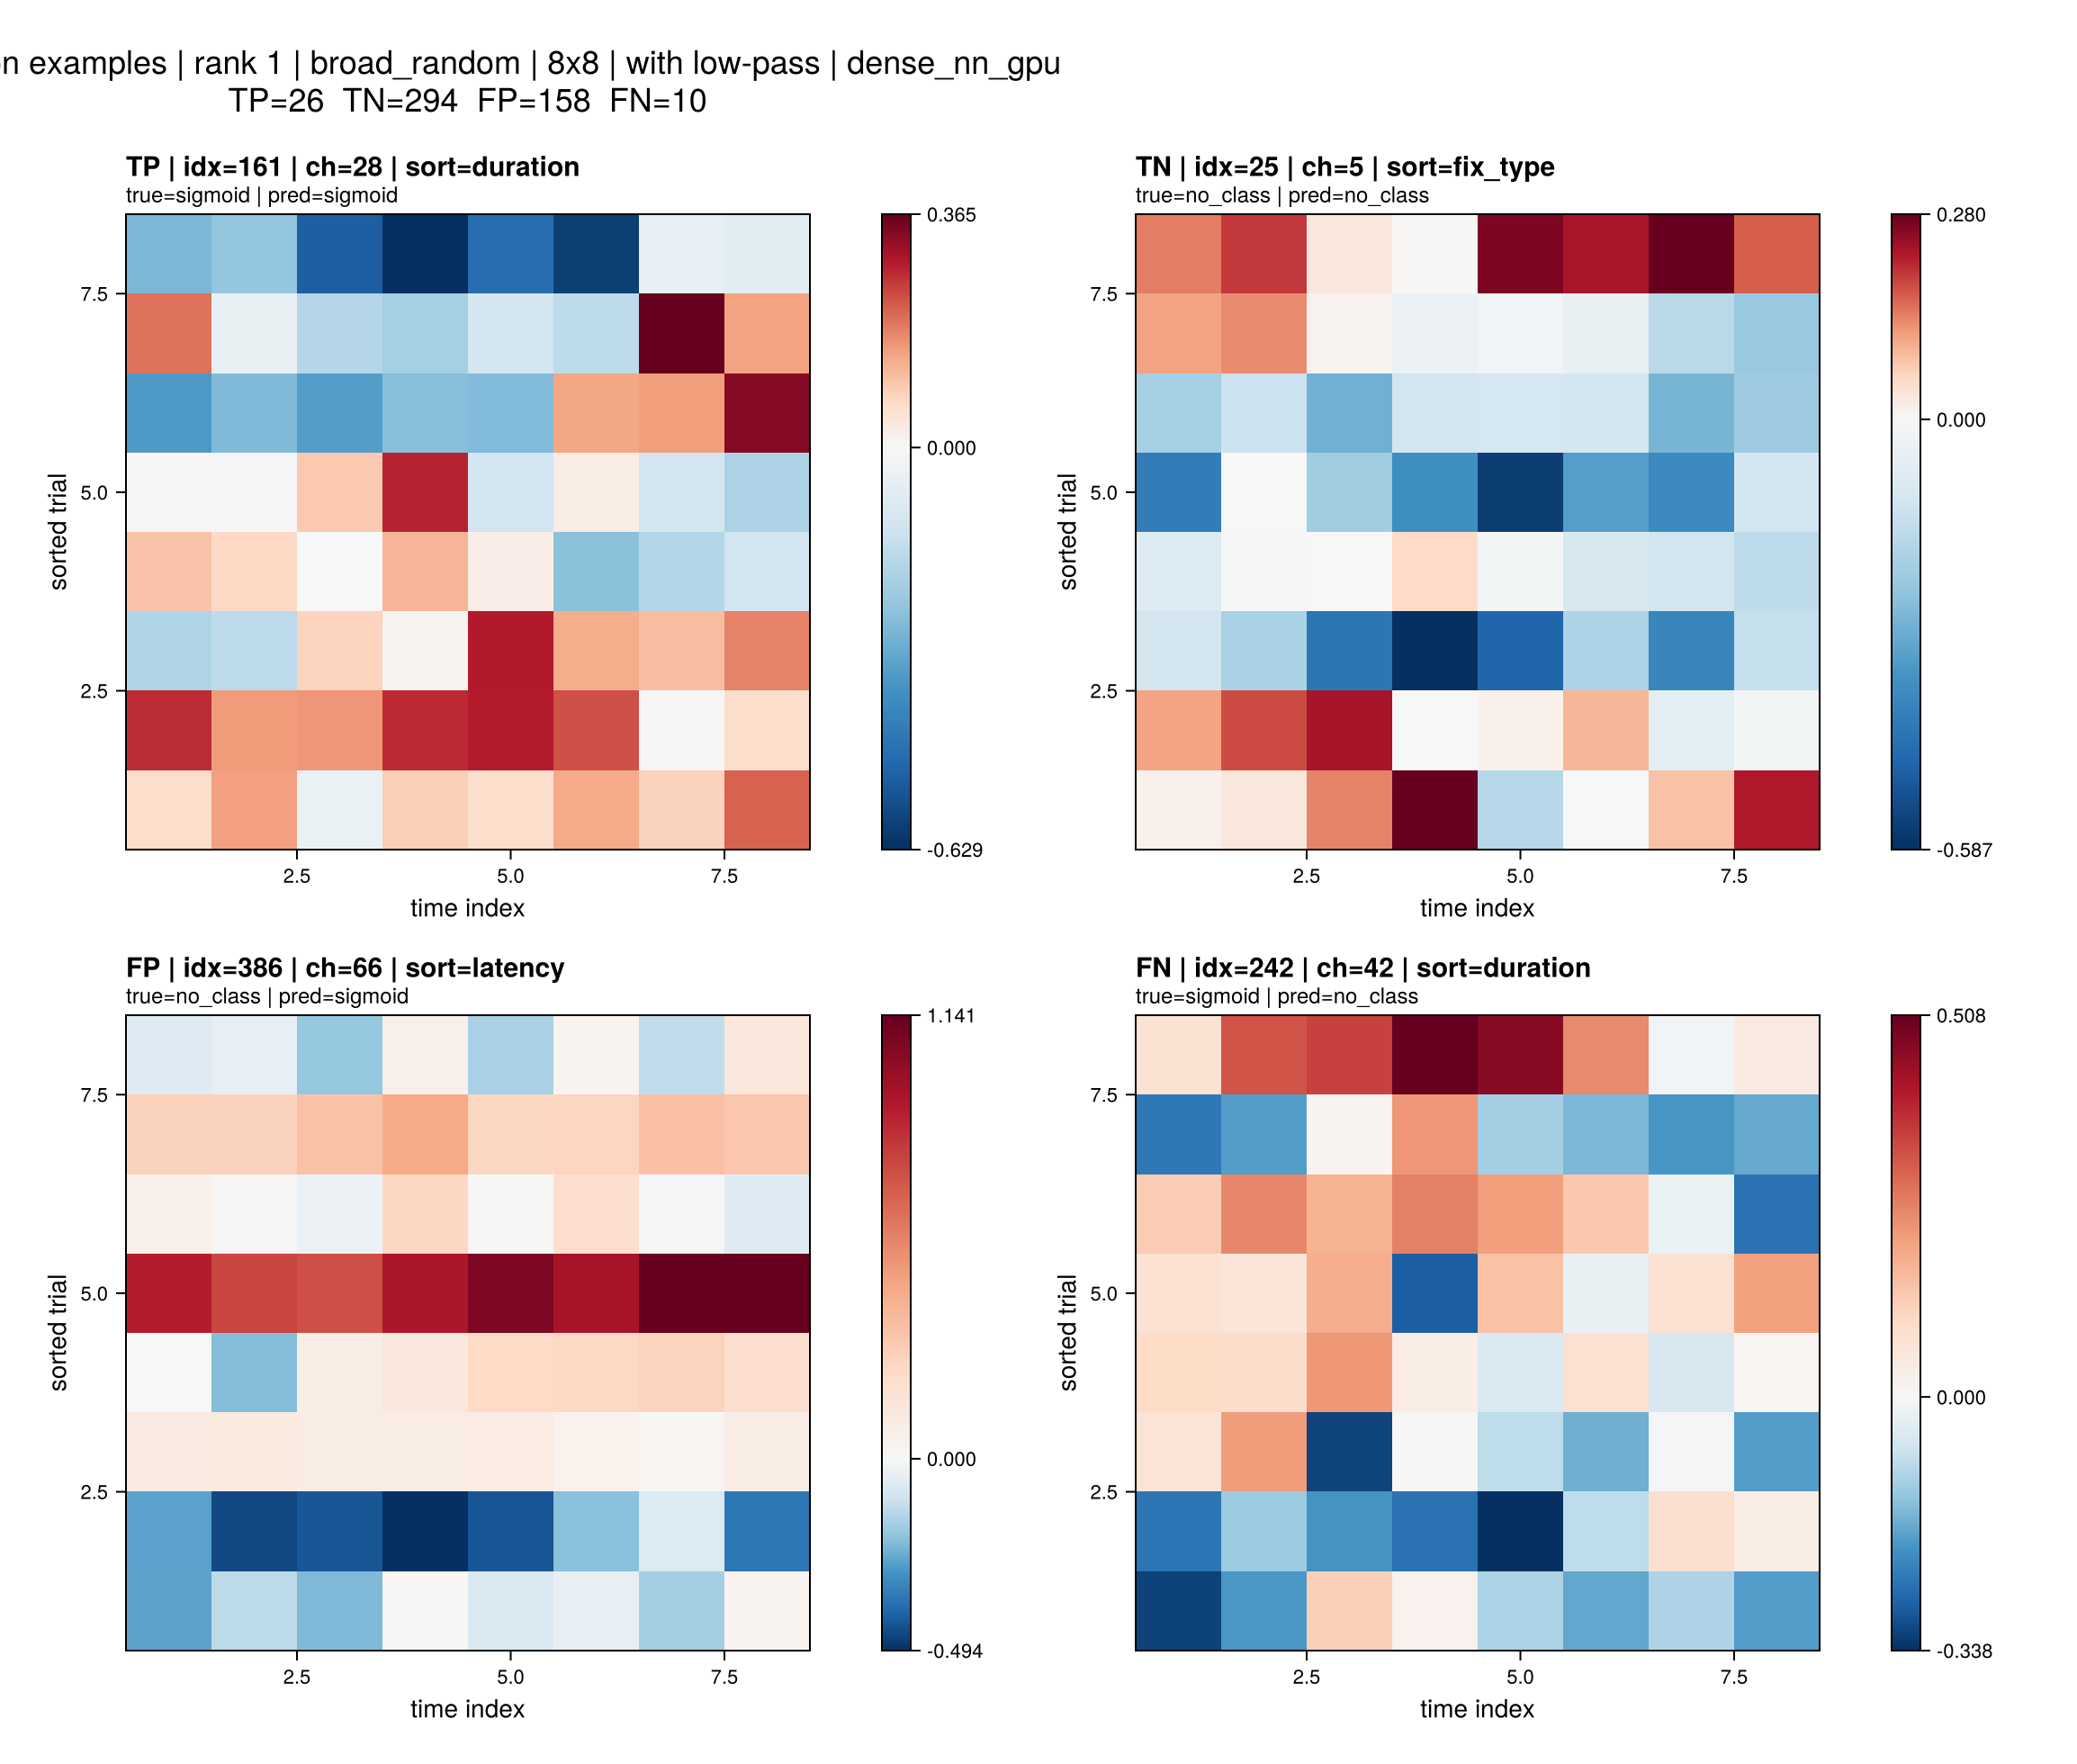

In [9]:
plot_confusion_examples(best_confusion_bundle)


## Dense NN Low-Pass Direct Search

This section implements a **second, more task-driven workflow**.
Instead of first calibrating the simulator with the feature-matching proxy and only then training the classifiers, this workflow directly optimizes simulator settings for:

- model: `dense_nn_gpu`
- preprocessing condition: `lowpass = true`

This workflow is useful when your practical question is not "Which simulator looks most realistic in feature space?" but rather:

> Which simulator settings lead to the best real-data Dense-NN performance under the low-pass condition?

The direct-search workflow still evaluates the three search methods:
- `broad_random`
- `latin_hypercube`
- `monte_carlo`

How candidate generation works in this section:

1. **Baseline seed**
   The normal `base_cfg` is always included as a seed configuration.

2. **Carry-over seed settings from previous runs**
   The workflow can reuse top settings from the earlier simulator-first workflow.
   These settings are taken from the ranked settings of previous runs and injected as additional seed configurations.

3. **Method-specific expansion**
   - `broad_random` adds extra globally random candidates across the full parameter ranges
   - `latin_hypercube` adds local candidates around the seed configurations using a structured LHS design
   - `monte_carlo` adds local random candidates around the seed configurations

How candidates are scored in this section:
- for each candidate, a simulated training set is generated
- the Dense NN is trained on that simulated set
- the trained model is evaluated on the real labeled dataset
- the main score is the mean `balanced_accuracy` across repeats
- `macro_f1`, recalls, and training time are stored as supporting diagnostics

Where to control the search budget:
- `NN_LOWPASS_SEARCH_METHOD_CANDIDATES`
  Sets how many total candidates each method evaluates. This count includes the carried-over seed configs.

- `NN_LOWPASS_SEARCH_EVAL_REPEATS`
  Repeats full training and evaluation per candidate and averages the score. Increase this if the direct-search results look noisy.

- `NN_LOWPASS_SEARCH_N_PER_PATTERN`
  Sets the amount of simulated training data per class for each candidate evaluation.

- `NN_LOWPASS_SEARCH_TOP_SETTINGS_PER_STRATEGY`
  Controls how many of the earlier top settings per strategy are reused as seed configurations.

- `NN_LOWPASS_SEARCH_MAX_SEED_STRATEGIES`
  Controls how many strategies from the previous ranking are allowed to contribute seed settings.

- `NN_LOWPASS_SEARCH_LOCAL_RANGE_SCALE`
  Controls how wide the local search window is around each seed configuration for the local LHS / Monte Carlo searches.

Interpretation:
- If this workflow beats the original proxy-guided settings, that suggests the proxy objective is not fully aligned with the actual Dense-NN task.
- If both workflows agree on similar regions of parameter space, that is a strong indication that the original simulator-first search is already pointing in the right direction.


In [10]:
# Where to set the search budget:
# - NN_LOWPASS_SEARCH_METHOD_CANDIDATES controls how many total candidates are evaluated per method
#   (including the carried-over seed configs from base_cfg + previous top settings).
# - NN_LOWPASS_SEARCH_EVAL_REPEATS repeats training per candidate and averages the score.
# - NN_LOWPASS_SEARCH_N_PER_PATTERN controls how many simulated repetitions per class are used.

NN_LOWPASS_SEARCH_TARGET_SIZE = (16, 16)
NN_LOWPASS_SEARCH_N_PER_PATTERN = 256
NN_LOWPASS_SEARCH_EVAL_REPEATS = 1

NN_LOWPASS_SEARCH_TOP_SETTINGS_PER_STRATEGY = 2
NN_LOWPASS_SEARCH_MAX_SEED_STRATEGIES = 3
NN_LOWPASS_SEARCH_LOCAL_RANGE_SCALE = 0.25

NN_LOWPASS_SEARCH_METHOD_CANDIDATES = Dict(
    :broad_random => 12,
    :latin_hypercube => 12,
    :monte_carlo => 12,
)


Dict{Symbol, Int64} with 3 entries:
  :monte_carlo     => 12
  :broad_random    => 12
  :latin_hypercube => 12

In [11]:
dense_nn_lowpass_search = run_dense_nn_lowpass_search(
    experiment;
    target_size = NN_LOWPASS_SEARCH_TARGET_SIZE,
    lowpass = true,
    ranked_results = result_tables.ranked,
    method_candidates = NN_LOWPASS_SEARCH_METHOD_CANDIDATES,
    n_per_pattern = NN_LOWPASS_SEARCH_N_PER_PATTERN,
    eval_repeats = NN_LOWPASS_SEARCH_EVAL_REPEATS,
    top_settings_per_strategy = NN_LOWPASS_SEARCH_TOP_SETTINGS_PER_STRATEGY,
    max_seed_strategies = NN_LOWPASS_SEARCH_MAX_SEED_STRATEGIES,
    local_range_scale = NN_LOWPASS_SEARCH_LOCAL_RANGE_SCALE,
    nn_batch_size = NN_BATCH_SIZE,
    nn_epochs = NN_EPOCHS,
    nn_lr = NN_LR,
    seed = BASE_SEED,
)



Dense NN low-pass search | method=broad_random | target=16x16 | candidates=12
  evaluating candidate 1/12 | source=seed_config | seed=base_cfg
    dense_nn epoch 1/30 | loss=0.58773
    dense_nn epoch 6/30 | loss=0.03953
    dense_nn epoch 12/30 | loss=0.0056
    dense_nn epoch 18/30 | loss=0.00211
    dense_nn epoch 24/30 | loss=0.00117
    dense_nn epoch 30/30 | loss=0.00254
  evaluating candidate 2/12 | source=seed_config | seed=broad_random#1
    dense_nn epoch 1/30 | loss=0.65274
    dense_nn epoch 6/30 | loss=0.08328
    dense_nn epoch 12/30 | loss=0.00913
    dense_nn epoch 18/30 | loss=0.00296
    dense_nn epoch 24/30 | loss=0.00278
    dense_nn epoch 30/30 | loss=0.00288
  evaluating candidate 3/12 | source=seed_config | seed=broad_random#2
    dense_nn epoch 1/30 | loss=0.78833
    dense_nn epoch 6/30 | loss=0.16995
    dense_nn epoch 12/30 | loss=0.01898
    dense_nn epoch 18/30 | loss=0.00757
    dense_nn epoch 24/30 | loss=0.00946
    dense_nn epoch 30/30 | loss=0.02565
 

(results_df = 36×64 DataFrame
 Row │ search_method  resolution  lowpass  candidate_index  candidate_source   ⋯
     │ String         String      Bool     Int64            String             ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ broad_random   16x16          true                1  seed_config        ⋯
   2 │ broad_random   16x16          true                6  seed_config
   3 │ broad_random   16x16          true                5  seed_config
   4 │ broad_random   16x16          true                4  seed_config
   5 │ broad_random   16x16          true               11  global_random      ⋯
   6 │ broad_random   16x16          true               10  global_random
   7 │ broad_random   16x16          true                2  seed_config
   8 │ broad_random   16x16          true                9  global_random
  ⋮  │       ⋮            ⋮          ⋮            ⋮                ⋮           ⋱
  30 │ monte_carlo    16x16          true       

In [12]:
dense_nn_lowpass_search.previous_seed_settings_df[:, [
    :strategy_priority,
    :strategy,
    :setting_rank,
    :setting_source,
    :setting_candidate,
    :setting_score,
]]


Row,strategy_priority,strategy,setting_rank,setting_source,setting_candidate,setting_score
,Int64,String,Int64,String,Int64?,Float64?
1,1,broad_random,1,random_sample,missing,missing
2,1,broad_random,2,random_sample,missing,missing
3,2,lhs_calibrated,1,lhs_top_candidate,10,0.363161
4,2,lhs_calibrated,2,lhs_top_candidate,8,0.489631
5,3,mc_random_search,1,mc_top_candidate,9,0.365772
6,3,mc_random_search,2,mc_top_candidate,1,0.435751


In [13]:
dense_nn_lowpass_search.summary_df

first(
    dense_nn_lowpass_search.results_df[:, [
        :search_method,
        :method_rank,
        :candidate_source,
        :seed_label,
        :mean_balanced_accuracy,
        :std_balanced_accuracy,
        :mean_macro_f1,
        :mean_train_time_s,
    ]],
    18,
)


Row,search_method,method_rank,candidate_source,seed_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_train_time_s
,String,Int64,String,String,Float64,Float64,Float64,Float64
1,broad_random,1,seed_config,base_cfg,0.685472,0.0,0.569819,0.751844
2,broad_random,2,seed_config,mc_random_search#1,0.66765,0.0,0.571453,0.77438
3,broad_random,3,seed_config,lhs_calibrated#2,0.646264,0.0,0.632366,0.707366
4,broad_random,4,seed_config,lhs_calibrated#1,0.645157,0.0,0.505528,0.730912
5,broad_random,5,global_random,global_random,0.629794,0.0,0.569087,0.695
6,broad_random,6,global_random,global_random,0.616888,0.0,0.589961,0.726185
7,broad_random,7,seed_config,broad_random#1,0.61615,0.0,0.516091,0.739046
8,broad_random,8,global_random,global_random,0.563791,0.0,0.424869,0.714821
9,broad_random,9,seed_config,broad_random#2,0.552606,0.0,0.43477,0.752051


## Best Dense-NN Low-Pass Run: Real vs. Simulated Metrics

The table below isolates **one single candidate**: the run that achieved the best classification performance on the **real labeled evaluation data**.
The ranking is still based on the real-data metrics first, using:

1. `mean_balanced_accuracy`
2. `mean_macro_f1`
3. `std_balanced_accuracy` as an additional tie-breaker

For that same candidate, the second table adds the corresponding metrics on the **simulated training data** used during the search evaluation.
These simulated metrics are shown only as an inspection aid. They are **in-sample diagnostics**, so they should not be interpreted as the main model-selection criterion.


In [14]:
best_dense_nn_lowpass_real = sort(
    copy(dense_nn_lowpass_search.results_df),
    [:mean_balanced_accuracy, :mean_macro_f1, :std_balanced_accuracy];
    rev = [true, true, false],
)[1, :]

best_dense_nn_lowpass_real_run_df = DataFrame(
    search_method = [best_dense_nn_lowpass_real.search_method],
    method_rank = [best_dense_nn_lowpass_real.method_rank],
    candidate_source = [best_dense_nn_lowpass_real.candidate_source],
    seed_label = [best_dense_nn_lowpass_real.seed_label],
    seed_origin = [best_dense_nn_lowpass_real.seed_origin],
    source_strategy = [best_dense_nn_lowpass_real.source_strategy],
    source_setting_rank = [best_dense_nn_lowpass_real.source_setting_rank],
    mean_train_time_s = [best_dense_nn_lowpass_real.mean_train_time_s],
    n_train = [best_dense_nn_lowpass_real.n_train],
    n_real = [best_dense_nn_lowpass_real.n_real],
)

best_dense_nn_lowpass_real_metrics_df = DataFrame(
    dataset = ["real_labeled_eval", "simulated_train_set"],
    balanced_accuracy = [
        best_dense_nn_lowpass_real.mean_balanced_accuracy,
        best_dense_nn_lowpass_real.mean_sim_balanced_accuracy,
    ],
    macro_f1 = [
        best_dense_nn_lowpass_real.mean_macro_f1,
        best_dense_nn_lowpass_real.mean_sim_macro_f1,
    ],
    recall_no_class = [
        best_dense_nn_lowpass_real.mean_recall_no_class,
        best_dense_nn_lowpass_real.mean_sim_recall_no_class,
    ],
    recall_sigmoid = [
        best_dense_nn_lowpass_real.mean_recall_sigmoid,
        best_dense_nn_lowpass_real.mean_sim_recall_sigmoid,
    ],
)

display(best_dense_nn_lowpass_real_run_df)
best_dense_nn_lowpass_real_metrics_df


Row,search_method,method_rank,candidate_source,seed_label,seed_origin,source_strategy,source_setting_rank,mean_train_time_s,n_train,n_real
,String,Int64,String,String,String,String,Int64,Float64,Int64,Int64
1,monte_carlo,1,seed_config,base_cfg,baseline,base_cfg,0,0.764795,512,488


Row,dataset,balanced_accuracy,macro_f1,recall_no_class,recall_sigmoid
,String,Float64,Float64,Float64,Float64
1,real_labeled_eval,0.755777,0.679801,0.900442,0.611111
2,simulated_train_set,1.0,1.0,1.0,1.0


In [19]:
best_mc_row = sort(
    copy(
        dense_nn_lowpass_search.results_df[
            (dense_nn_lowpass_search.results_df.search_method .== "monte_carlo") .&
            (dense_nn_lowpass_search.results_df.candidate_source .== "mc_local"),
            :
        ]
    ),
    [:mean_balanced_accuracy, :mean_macro_f1, :std_balanced_accuracy];
    rev = [true, true, false],
)[1, :]

base_cfg = SmallScaleERPClassification.make_base_config(
    target_size = dense_nn_lowpass_search.target_size,
    apply_lowpass = dense_nn_lowpass_search.lowpass,
)

param_infos = SmallScaleERPClassification.parameter_infos(base_cfg)

best_mc_meta_df = DataFrame(
    search_method = [best_mc_row.search_method],
    method_rank = [best_mc_row.method_rank],
    candidate_source = [best_mc_row.candidate_source],
    seed_label = [best_mc_row.seed_label],
    seed_origin = [best_mc_row.seed_origin],
    source_strategy = [best_mc_row.source_strategy],
    source_setting_rank = [best_mc_row.source_setting_rank],
    mean_balanced_accuracy = [best_mc_row.mean_balanced_accuracy],
    mean_macro_f1 = [best_mc_row.mean_macro_f1],
    mean_sim_balanced_accuracy = [best_mc_row.mean_sim_balanced_accuracy],
    mean_sim_macro_f1 = [best_mc_row.mean_sim_macro_f1],
)

best_mc_params_df = DataFrame(
    parameter = [info.label for info in param_infos],
    field = [String(info.field) for info in param_infos],
    column = [String(info.symbol) for info in param_infos],
    value = [Float64(best_mc_row[info.symbol]) for info in param_infos],
)

display(best_mc_meta_df)
show(stdout, MIME"text/plain"(), best_mc_params_df; allrows = true, allcols = true, truncate = 0)
println()


Row,search_method,method_rank,candidate_source,seed_label,seed_origin,source_strategy,source_setting_rank,mean_balanced_accuracy,mean_macro_f1,mean_sim_balanced_accuracy,mean_sim_macro_f1
,String,Int64,String,String,String,String,Int64,Float64,Float64,Float64,Float64
1,monte_carlo,4,mc_local,lhs_calibrated#2,previous_run,lhs_calibrated,2,0.672689,0.565178,1.0,1.0


38×4 DataFrame
 Row │ parameter                                       field   column                  value      
     │ String                                          String  String                  Float64    
─────┼────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sim.mu_dist.mu                                  mean    sim_mu_mean              4.46205
   2 │ sim.mu_dist.sigma                               std     sim_mu_std               0.240548
   3 │ sim.sigma_dist.mu                               mean    sim_sigma_mean           0.795007
   4 │ sim.sigma_dist.sigma                            std     sim_sigma_std            0.132236
   5 │ components.p100_width_dist.mu                   mean    p100_width_mean          0.093166
   6 │ components.p100_width_dist.sigma                std     p100_width_std           0.0185826
   7 │ components.n170_width_dist.mu                   mean    n170_width_mean          0.165376
   8 │ co